In [ ]:
# Run in Google Colab
from google.colab import drive
drive.mount('/content/drive')  # follow the auth link

# Set dataset path on your Drive:
DATA_ROOT = '/content/drive/MyDrive/IMS'


Mounted at /content/drive


### Testing with an external dataset

To test the trained models with a new dataset from a different source, you need to ensure the new dataset is structured similarly to the IMS data (i.e., `.txt` files containing vibration data within a root directory). You will define the path to this new dataset, extract features using the same methodology, apply a labeling strategy (such as the proxy labels used for `df2` and `df3`), and then evaluate the performance of the previously trained models.

In [ ]:
# Define the root path for your external dataset
# IMPORTANT: Replace '/content/drive/MyDrive/MyNewBearingData' with the actual path to your external dataset
# Ensure your Google Drive is mounted if the data is there, or adjust the path accordingly.
EXTERNAL_DATA_ROOT = "/content/drive/MyDrive/MyNewBearingData"
NEW_DATASET_NAME = "my_external_dataset" # A descriptive name for your new dataset

# Create a function to load features from an external dataset root
def load_external_dataset_features(root_path, set_name):
    # Assumes the 'features' function is already defined in a previous cell
    # and the dataset consists of files (e.g., .txt) containing numerical data.
    files = sorted([p for p in glob.glob(os.path.join(root_path, "**", "*"), recursive=True) if os.path.isfile(p)])
    rows = []
    print(f"Found {len(files)} files in {root_path} for {set_name}.")
    for i, f in enumerate(files):
        try:
            sig = np.loadtxt(f)
            feat = features(sig) # Reuse the 'features' function defined earlier
            feat.update({"set": set_name, "file_index": i, "path": f})
            rows.append(feat)
        except Exception as e:
            print(f"Could not process file {f}: {e}")
            continue
    return pd.DataFrame(rows)

# Load features for the external dataset
df_external = load_external_dataset_features(EXTERNAL_DATA_ROOT, NEW_DATASET_NAME)

# Display the head of the new DataFrame
print(f"\nFeatures extracted for {NEW_DATASET_NAME}:")
display(df_external.head())

In [ ]:
# Apply proxy labels to the external dataset for binary classification (healthy vs fault)
# The 'proxy_labels' function was defined previously and is reused here.
if not df_external.empty:
    df_external["label3"] = proxy_labels(df_external)
    df_external["label_bin"] = np.where(df_external["label3"] == "healthy", "healthy", "fault")
    print(f"\nLabels applied for {NEW_DATASET_NAME}:")
    display(df_external[['file_index', 'label3', 'label_bin']].head())
    print("\nValue counts for 'label_bin':")
    print(df_external['label_bin'].value_counts())
else:
    print("No data in df_external to apply labels.")

In [ ]:
# Evaluate the best Stage-1 model (clf1) on the external dataset
if not df_external.empty and 'label_bin' in df_external.columns:
    X_external = df_external[Xcols].values
    y_external = df_external["label_bin"].values

    # Ensure clf1 is the best model from Stage-1 training (defined in previous cells)
    # Assuming 'clf1' is already fitted to df1's Stage-1 training data.
    if 'clf1' in locals() or 'clf1' in globals():
        y_external_pred = clf1.predict(X_external)

        print(f"\nEvaluation results for '{NEW_DATASET_NAME}' using the best Stage-1 model ({best1}):")
        print(classification_report(y_external, y_external_pred, digits=3, zero_division=0))

        # Optional: Visualize predictions
        idx_external = df_external["file_index"].values
        plt.figure(figsize=(12,3))
        plt.plot(idx_external, (y_external=="fault").astype(int), label="true")
        plt.plot(idx_external, (y_external_pred=="fault").astype(int), label="pred", alpha=0.7)
        plt.title(f"Stage-1 true vs pred on {NEW_DATASET_NAME} ({best1})")
        plt.xlabel("file index")
        plt.ylabel("fault=1")
        plt.legend()
        plt.show()
    else:
        print("Error: Stage-1 model 'clf1' not found. Please ensure previous cells were executed.")
else:
    print("Cannot evaluate: df_external is empty or 'label_bin' column is missing.")

In [ ]:
import os

DATA_ROOT = '/content/drive/MyDrive/IMS'


if os.path.exists(DATA_ROOT):
    print("Dataset folder found:", DATA_ROOT)
else:
    print(" Folder not found! Double-check the folder name and path.")

print("\nTop-level contents:\n")
for name in sorted(os.listdir(DATA_ROOT)):
    path = os.path.join(DATA_ROOT, name)
    if os.path.isdir(path):
        print("📁", name)
    else:
        print("📄", name)


Dataset folder found: /content/drive/MyDrive/IMS

Top-level contents:

📁 1st_test
📄 1st_test.rar
📁 2nd_test
📄 2nd_test.rar
📁 3rd_test
📄 3rd_test.rar
📄 Readme Document for IMS Bearing Data.pdf
📄 bearing_rl_data.pkl
📁 extracted


In [ ]:
print("\nFull folder tree:\n")

for root, dirs, files in os.walk(DATA_ROOT):
    level = root.replace(DATA_ROOT, "").count(os.sep)
    indent = "   " * level
    print(f"{indent}📁 {os.path.basename(root)}/")
    sub_indent = "   " * (level + 1)
    for f in files:
        print(f"{sub_indent}📄 {f}")


Streaming output truncated to the last 5000 lines.
         📄 2003.10.29.18.39.46
         📄 2003.10.29.19.09.46
         📄 2003.10.29.18.59.46
         📄 2003.10.29.19.19.46
         📄 2003.10.29.19.29.46
         📄 2003.10.29.19.49.46
         📄 2003.10.29.19.59.46
         📄 2003.10.29.19.39.46
         📄 2003.10.29.20.19.46
         📄 2003.10.29.20.09.46
         📄 2003.10.29.20.29.46
         📄 2003.10.29.20.39.46
         📄 2003.10.29.20.49.46
         📄 2003.10.29.20.59.46
         📄 2003.10.29.21.09.46
         📄 2003.10.29.21.19.46
         📄 2003.10.29.21.29.46
         📄 2003.10.29.21.39.46
         📄 2003.10.29.21.49.46
         📄 2003.10.29.22.09.46
         📄 2003.10.29.21.59.46
         📄 2003.10.29.22.29.46
         📄 2003.10.29.22.19.46
         📄 2003.10.29.22.39.46
         📄 2003.10.29.22.49.46
         📄 2003.10.29.22.59.46
         📄 2003.10.29.23.19.46
         📄 2003.10.29.23.09.46
         📄 2003.10.29.23.39.46
         📄 2003.10.29.23.29.46
         📄 2003.10.

In [ ]:
!apt-get install unrar


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


In [ ]:
#!rm -rf /content/drive/MyDrive/IMS/extracted


In [ ]:
import os

base = '/content/drive/MyDrive/IMS'

os.makedirs(base + '/extracted', exist_ok=True)

!unrar x "{base}/1st_test.rar" "{base}/extracted/1st_test/"
!unrar x "{base}/2nd_test.rar" "{base}/extracted/2nd_test/"
!unrar x "{base}/3rd_test.rar" "{base}/extracted/3rd_test/"


Streaming output truncated to the last 5000 lines.
Extracting  /content/drive/MyDrive/IMS/extracted/3rd_test/4th_test/txt/2004.03.13.14.12.46      17%  OK 
Extracting  /content/drive/MyDrive/IMS/extracted/3rd_test/4th_test/txt/2004.03.13.14.22.46      17%  OK 
Extracting  /content/drive/MyDrive/IMS/extracted/3rd_test/4th_test/txt/2004.03.13.14.32.46      17%  OK 
Extracting  /content/drive/MyDrive/IMS/extracted/3rd_test/4th_test/txt/2004.03.13.14.42.46      17%  OK 
Extracting  /content/drive/MyDrive/IMS/extracted/3rd_test/4th_test/txt/2004.03.13.14.52.46      17%  OK 
Extracting  /content/drive/MyDrive/IMS/extracted/3rd_test/4th_test/txt/2004.03.13.15.02.46      18%  OK 
Extracting  /content/drive/MyDrive/IMS/extracted/3rd_test/4th_test/txt/2004.03.13.15.12.46      18%  OK 
Extracting  /content/drive/MyDrive/IMS/extracted/3rd_test/4th_test/txt/2004.03.13.15.22.46      18%  OK 
Extracting  /content/drive/MyDrive/IM

In [ ]:
import glob

extracted_root = '/content/drive/MyDrive/IMS/extracted'

for folder in ['1st_test', '2nd_test', '3rd_test']:
    files = glob.glob(os.path.join(extracted_root, folder, '*'))
    print(folder, ':', len(files), 'files')
    print('Sample files:', files[:3])
    print()


1st_test : 1 files
Sample files: ['/content/drive/MyDrive/IMS/extracted/1st_test/1st_test']

2nd_test : 1 files
Sample files: ['/content/drive/MyDrive/IMS/extracted/2nd_test/2nd_test']

3rd_test : 1 files
Sample files: ['/content/drive/MyDrive/IMS/extracted/3rd_test/4th_test']



In [ ]:
import glob

base = '/content/drive/MyDrive/IMS/extracted'

for folder in ['1st_test', '2nd_test', '3rd_test']:
    print(f"\n--- {folder} ---")
    files = glob.glob(os.path.join(base, folder, '**', '*.*'), recursive=True)
    data_files = [f for f in files if os.path.isfile(f)]
    print(f"Found {len(data_files)} files.")
    if data_files:
        with open(data_files[0], 'r', errors='ignore') as f:
            lines = [next(f).strip() for _ in range(5)]
        print("\nFirst 5 lines from", os.path.basename(data_files[0]), ":")
        for line in lines:
            print(line)



--- 1st_test ---
Found 2156 files.

First 5 lines from 2003.10.22.12.06.24 :
-0.022	-0.039	-0.183	-0.054	-0.105	-0.134	-0.129	-0.142
-0.105	-0.017	-0.164	-0.183	-0.049	0.029	-0.115	-0.122
-0.183	-0.098	-0.195	-0.125	-0.005	-0.007	-0.171	-0.071
-0.178	-0.161	-0.159	-0.178	-0.100	-0.115	-0.112	-0.078
-0.208	-0.129	-0.261	-0.098	-0.151	-0.205	-0.063	-0.066

--- 2nd_test ---
Found 984 files.

First 5 lines from 2004.02.12.10.32.39 :
-0.049	-0.071	-0.132	-0.010
-0.042	-0.073	-0.007	-0.105
0.015	0.000	0.007	0.000
-0.051	0.020	-0.002	0.100
-0.107	0.010	0.127	0.054

--- 3rd_test ---
Found 758 files.

First 5 lines from 2004.03.04.09.27.46 :
0.034	0.264	0.039	-0.046
0.103	0.083	-0.061	-0.012
0.095	-0.039	-0.007	0.039
0.000	0.110	0.022	-0.002
0.005	0.154	-0.127	-0.020


RMS(to see vibration degredation ) and kurtosis (spikiness) trend plot

1st_test 2156
example: /content/drive/MyDrive/IMS/extracted/1st_test/1st_test/2003.10.22.12.06.24
2nd_test 984
example: /content/drive/MyDrive/IMS/extracted/2nd_test/2nd_test/2004.02.12.10.32.39
3rd_test 6324
example: /content/drive/MyDrive/IMS/extracted/3rd_test/4th_test/txt/2004.03.04.09.27.46
using files: 2156
rms count: 2156


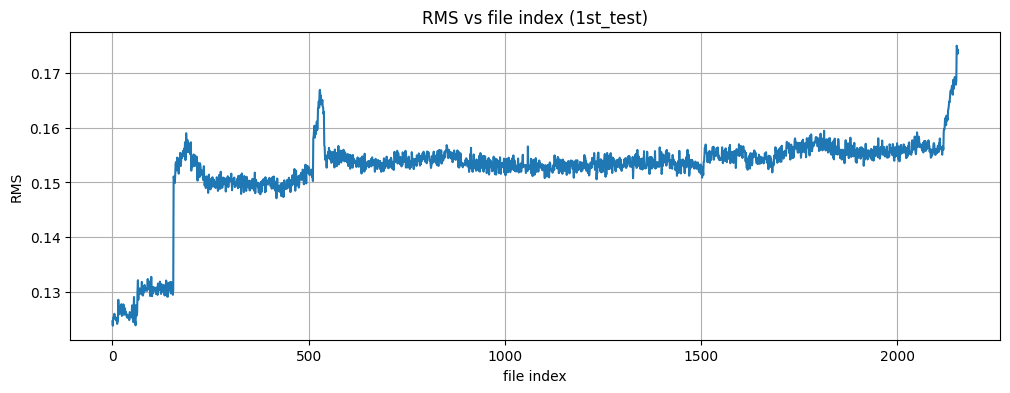

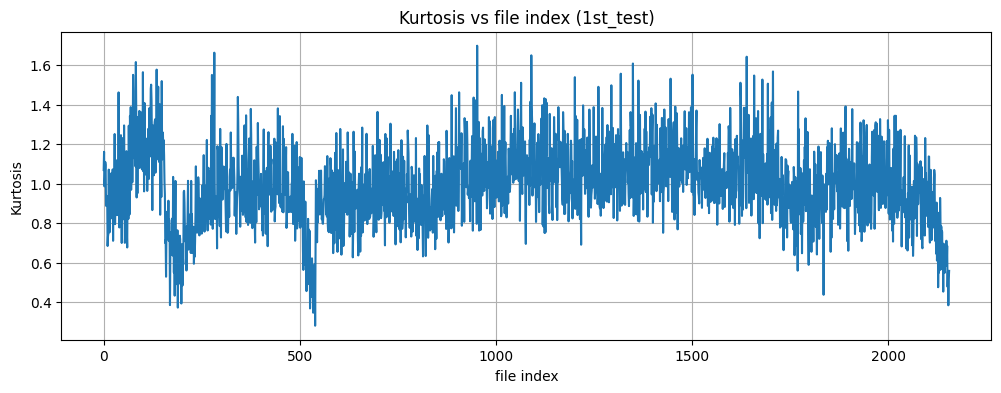

In [ ]:
import os, glob, numpy as np, matplotlib.pyplot as plt
from scipy.stats import kurtosis

ROOT = "/content/drive/MyDrive/IMS/extracted"

def all_files(test):
    base = os.path.join(ROOT, test)
    return [p for p in glob.glob(os.path.join(base, "**", "*"), recursive=True) if os.path.isfile(p)]

# check where the files actually are
for t in ["1st_test","2nd_test","3rd_test"]:
    f = all_files(t)
    print(t, len(f))
    if f: print("example:", f[0])

# use 1st_test for exploration
files = sorted(all_files("1st_test"))
print("using files:", len(files))

rms_vals = []
kurt_vals = []

for f in files:
    x = np.loadtxt(f)
    if x.ndim == 2:
        ch = x[:,0]
    elif x.ndim == 1:
        ch = x
    else:
        continue
    rms_vals.append(np.sqrt(np.mean(ch**2)))
    kurt_vals.append(kurtosis(ch, fisher=True))

print("rms count:", len(rms_vals))

plt.figure(figsize=(12,4))
plt.plot(rms_vals)
plt.title("RMS vs file index (1st_test)")
plt.xlabel("file index")
plt.ylabel("RMS")
plt.grid(True)
plt.show()

plt.figure(figsize=(12,4))
plt.plot(kurt_vals)
plt.title("Kurtosis vs file index (1st_test)")
plt.xlabel("file index")
plt.ylabel("Kurtosis")
plt.grid(True)
plt.show()


Building labeled dataset

In [ ]:
import numpy as np
import glob
import os
import pandas as pd
from scipy.stats import kurtosis

# Path to extracted 1st_test
DATA_ROOT = "/content/drive/MyDrive/IMS/extracted/1st_test"

# Collect all files (remove folders)
files = sorted([f for f in glob.glob(os.path.join(DATA_ROOT, "**", "*"), recursive=True)
                if os.path.isfile(f)])

print("Total files found:", len(files))

# Prepare lists
file_index_list = []
rms_list = []
kurt_list = []
label_list = []

# Label ranges
def get_label(idx):
    if idx < 300:
        return "healthy"
    elif idx < 2000:
        return "degraded"
    else:
        return "failing"

# Extract features
for idx, fpath in enumerate(files):
    data = np.loadtxt(fpath)

    # handle 1D or 2D
    if data.ndim == 2:
        sig = data[:,0]   # channel 0
    else:
        sig = data

    rms = np.sqrt(np.mean(sig**2))
    k = kurtosis(sig, fisher=True)

    file_index_list.append(idx)
    rms_list.append(rms)
    kurt_list.append(k)
    label_list.append(get_label(idx))

# Build dataframe
df = pd.DataFrame({
    "file_index": file_index_list,
    "rms": rms_list,
    "kurtosis": kurt_list,
    "label": label_list
})

# Save it
OUT_CSV = "/content/drive/MyDrive/IMS/ims_labeled_features.csv"
df.to_csv(OUT_CSV, index=False)

print("Saved labeled dataset to:", OUT_CSV)
df.head()


Total files found: 2156
Saved labeled dataset to: /content/drive/MyDrive/IMS/ims_labeled_features.csv


,file_index,rms,kurtosis,label
0,0,0.124614,1.069163,healthy
1,1,0.123811,1.161552,healthy
2,2,0.125246,0.986286,healthy
3,3,0.125197,1.034294,healthy
4,4,0.125618,1.110164,healthy


lets have some visuals to confirm

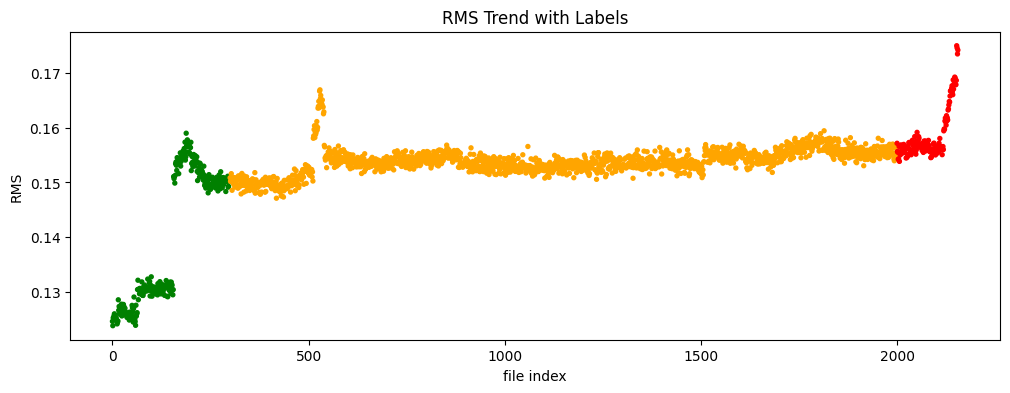

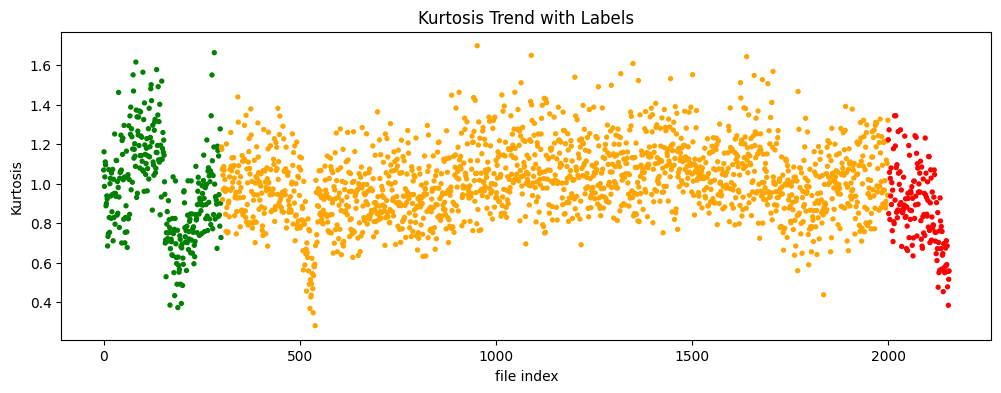

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.scatter(df["file_index"], df["rms"], c=df["label"].map({"healthy":"green", "degraded":"orange","failing":"red"}), s=8)
plt.title("RMS Trend with Labels")
plt.xlabel("file index")
plt.ylabel("RMS")
plt.show()

plt.figure(figsize=(12,4))
plt.scatter(df["file_index"], df["kurtosis"], c=df["label"].map({"healthy":"green", "degraded":"orange","failing":"red"}), s=8)
plt.title("Kurtosis Trend with Labels")
plt.xlabel("file index")
plt.ylabel("Kurtosis")
plt.show()


In [ ]:
samples per class

In [ ]:
df['label'].value_counts()


,count
label,
degraded,1700
healthy,300
failing,156


building features for all the set


In [ ]:
import os, glob, numpy as np, pandas as pd
from scipy.stats import kurtosis
from scipy.signal import butter, filtfilt, hilbert, welch

ROOT = "/content/drive/MyDrive/IMS/extracted"
FS = 20000
NYQ = FS/2

def butter_band(x, low, high):
    low = max(1e-6, low/NYQ); high = min(0.999, high/NYQ)
    b,a = butter(4, [low, high], btype="band")
    return filtfilt(b,a,x)

def band_energy_welch(x, a, b):
    f, Pxx = welch(x, fs=FS, nperseg=1024)
    m = (f>=a) & (f<b)
    return float(Pxx[m].sum())

def features(sig):
    x = sig[:,0] if sig.ndim==2 else sig
    x = x.astype(np.float32)

    rms = float(np.sqrt(np.mean(x**2)))
    mean = float(np.mean(x))
    std = float(np.std(x))
    ptp = float(x.max()-x.min())
    crest = float((np.max(np.abs(x)) / (rms+1e-12)))
    mad = float(np.mean(np.abs(x-mean)))
    kur = float(kurtosis(x, fisher=True))

    x_hp = butter_band(x, 3000, 9500)
    e48 = band_energy_welch(x_hp, 4000, 8000)
    e89 = band_energy_welch(x_hp, 8000, 9500)

    x_env = np.abs(hilbert(butter_band(x, 4000, 9000)))
    env_rms = float(np.sqrt(np.mean(x_env**2)))
    env_kur = float(kurtosis(x_env, fisher=True))

    return {
        "rms": rms, "std": std, "mad": mad, "ptp": ptp, "crest": crest, "kurtosis": kur,
        "band_4_8k": e48, "band_8_9k5": e89, "env_rms": env_rms, "env_kurtosis": env_kur
    }

def load_set(name):
    files = sorted([p for p in glob.glob(os.path.join(ROOT, name, "**", "*"), recursive=True) if os.path.isfile(p)])
    rows=[]
    for i,f in enumerate(files):
        sig = np.loadtxt(f)
        feat = features(sig)
        feat.update({"set":name,"file_index":i,"path":f})
        rows.append(feat)
    return pd.DataFrame(rows)

df1 = load_set("1st_test")
df2 = load_set("2nd_test")
df3 = load_set("3rd_test")


In [ ]:
# Stage-1: healthy vs fault
df1["label_bin"] = np.where(df1.file_index < 300, "healthy", "fault")

# Stage-2: degraded vs failing (threshold at 1800)
def label_stage2(idx):
    return "degraded" if idx < 1800 else "failing"
df1["label_stage2"] = df1.file_index.apply(label_stage2)

# Proxy labels for cross-dataset Stage-1
def proxy_labels(df, h_pct=0.15, f_pct=0.10):
    n=len(df); h_end=int(n*h_pct); f_start=n-int(n*f_pct)
    lab=np.array(["degraded"]*n, dtype=object); lab[:h_end]="healthy"; lab[f_start:]="failing"
    return lab
for d in (df2, df3):
    d["label3"] = proxy_labels(d)
    d["label_bin"] = np.where(d["label3"]=="healthy","healthy","fault")


time based split and  training on 6 models

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt
import numpy as np

Xcols = ["rms","std","mad","ptp","crest","kurtosis","band_4_8k","band_8_9k5","env_rms","env_kurtosis"]

models = {
    "LogReg": make_pipeline(StandardScaler(), LogisticRegression(max_iter=600, class_weight="balanced")),
    "SVM_RBF": make_pipeline(StandardScaler(), SVC(kernel="rbf", class_weight="balanced", probability=True)),
    "RandomForest": RandomForestClassifier(n_estimators=500, random_state=42, class_weight="balanced"),
    "GradBoost": GradientBoostingClassifier(),
    "KNN": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=7)),
    "GaussianNB": GaussianNB(),
}

def eval_models(Xtr,ytr,Xte,yte, models):
    rows=[]; reps={}
    for name, clf in models.items():
        clf.fit(Xtr,ytr)
        yp = clf.predict(Xte)
        rep = classification_report(yte, yp, digits=3, output_dict=True, zero_division=0)
        reps[name]=rep
        rows.append([name, rep["weighted avg"]["precision"], rep["weighted avg"]["recall"], rep["weighted avg"]["f1-score"]])
    out = pd.DataFrame(rows, columns=["model","precision","recall","f1"]).sort_values("f1", ascending=False)
    return out, reps


Stage-1 results
          model  precision    recall        f1
0        LogReg        1.0  1.000000  1.000000
1       SVM_RBF        1.0  1.000000  1.000000
2  RandomForest        1.0  1.000000  1.000000
3     GradBoost        1.0  1.000000  1.000000
4           KNN        1.0  1.000000  1.000000
5    GaussianNB        1.0  0.898876  0.946746


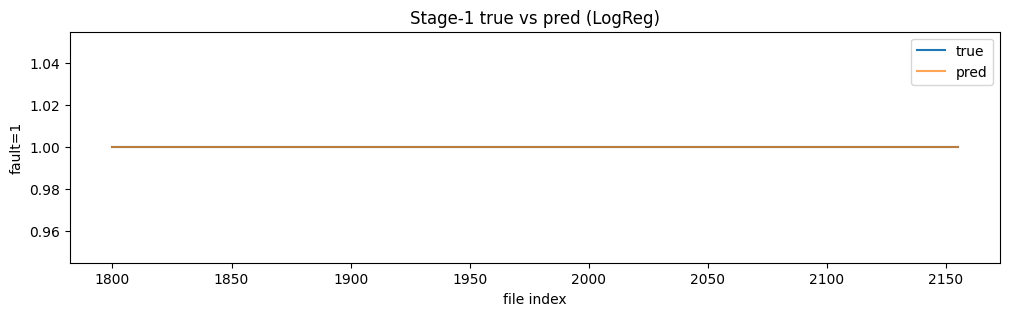

In [ ]:
split1 = 1800
X_tr = df1.loc[:split1-1, Xcols].values
y_tr = df1.loc[:split1-1, "label_bin"].values
X_te = df1.loc[split1:, Xcols].values
y_te = df1.loc[split1:, "label_bin"].values

res1, rep1 = eval_models(X_tr,y_tr,X_te,y_te,models)
print("Stage-1 results"); print(res1)

best1 = res1.iloc[0]["model"]; clf1 = models[best1].fit(X_tr,y_tr)
yhat = clf1.predict(X_te)

idx = df1.loc[split1:,"file_index"].values
plt.figure(figsize=(12,3))
plt.plot(idx, (y_te=="fault").astype(int), label="true")
plt.plot(idx, (yhat=="fault").astype(int), label="pred", alpha=0.7)
plt.title(f"Stage-1 true vs pred ({best1})"); plt.xlabel("file index"); plt.ylabel("fault=1"); plt.legend(); plt.show()


Stage-2 results
     model  precision    recall        f1
0   LogReg        1.0  0.993590  0.996785
1  SVM_RBF        1.0  0.826923  0.905263


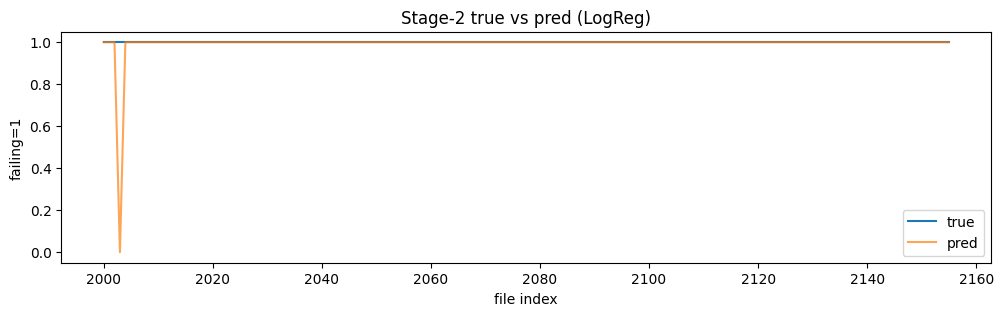

In [ ]:
train_mask = (df1.file_index>=300) & (df1.file_index<2000)
test_mask  = (df1.file_index>=2000)

X2_tr = df1.loc[train_mask, Xcols].values
y2_tr = df1.loc[train_mask, "label_stage2"].values
X2_te = df1.loc[test_mask, Xcols].values
y2_te = df1.loc[test_mask, "label_stage2"].values

top2 = list(res1["model"].head(2))
models2 = {k:models[k] for k in top2}
res2, rep2 = eval_models(X2_tr,y2_tr,X2_te,y2_te,models2)
print("Stage-2 results"); print(res2)

best2 = res2.iloc[0]["model"]; clf2 = models2[best2].fit(X2_tr,y2_tr)
y2p = clf2.predict(X2_te)

m = {"degraded":0,"failing":1}
idx2 = df1.loc[test_mask,"file_index"].values
plt.figure(figsize=(12,3))
plt.plot(idx2, [m[v] for v in y2_te], label="true")
plt.plot(idx2, [m[v] for v in y2p], label="pred", alpha=0.7)
plt.title(f"Stage-2 true vs pred ({best2})"); plt.xlabel("file index"); plt.ylabel("failing=1"); plt.legend(); plt.show()


In [ ]:
X1_full = df1[Xcols].values; y1_full = df1["label_bin"].values
X2 = df2[Xcols].values; y2 = df2["label_bin"].values
X3 = df3[Xcols].values; y3 = df3["label_bin"].values

rows=[]
for name, clf in models.items():
    clf.fit(X1_full, y1_full)
    y2p = clf.predict(X2); y3p = clf.predict(X3)
    r2 = classification_report(y2, y2p, digits=3, output_dict=True, zero_division=0)
    r3 = classification_report(y3, y3p, digits=3, output_dict=True, zero_division=0)
    rows.append([name, r2["weighted avg"]["f1-score"], r3["weighted avg"]["f1-score"]])
pd.DataFrame(rows, columns=["model","set2_f1","set3_f1"]).sort_values(["set2_f1","set3_f1"], ascending=False)


,model,set2_f1,set3_f1
1,SVM_RBF,0.781944,0.781215
2,RandomForest,0.597948,0.067568
4,KNN,0.505211,0.062884
0,LogReg,0.386201,0.042935
3,GradBoost,0.328533,0.041333
5,GaussianNB,0.038834,0.039084
